Observed conversion rate: 0.126

Frequentist hypothesis test
p-value: 0.034386053296832066
Conclusion: Reject the null hypothesis

Posterior distribution: Beta(73, 527)

Bayesian analysis
P(new design better than baseline): 0.9539489886137684


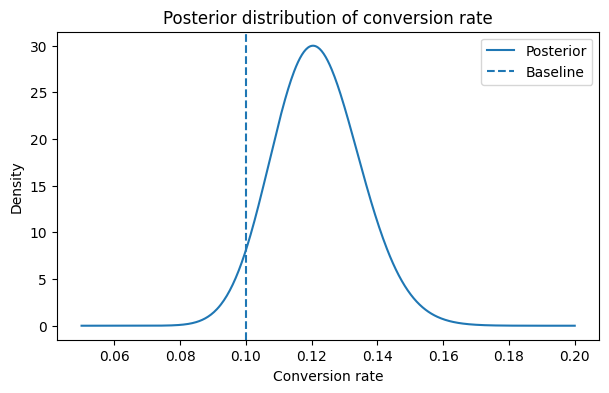

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest, beta

# ---------------------------
# Data
# ---------------------------

n = 500
conversions = 63
baseline = 0.10

observed_rate = conversions / n

print("Observed conversion rate:", observed_rate)

# ---------------------------
# Frequentist hypothesis test
# ---------------------------

test = binomtest(conversions, n, baseline, alternative="greater")

print("\nFrequentist hypothesis test")
print("p-value:", test.pvalue)

if test.pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis")
else:
    print("Conclusion: Fail to reject the null")

# ---------------------------
# Bayesian posterior
# ---------------------------

# Prior belief: conversion rate around 10%
alpha_prior = 10
beta_prior = 90

alpha_post = alpha_prior + conversions
beta_post = beta_prior + n - conversions

print("\nPosterior distribution: Beta({}, {})".format(alpha_post, beta_post))

# Probability new design is better
p_better = 1 - beta.cdf(baseline, alpha_post, beta_post)

print("\nBayesian analysis")
print("P(new design better than baseline):", p_better)

# ---------------------------
# Posterior visualization
# ---------------------------

x = np.linspace(0.05, 0.20, 500)

posterior = beta.pdf(x, alpha_post, beta_post)

plt.figure(figsize=(7,4))

plt.plot(x, posterior, label="Posterior")
plt.axvline(baseline, linestyle="--", label="Baseline")

plt.xlabel("Conversion rate")
plt.ylabel("Density")
plt.title("Posterior distribution of conversion rate")

plt.legend()
plt.show()

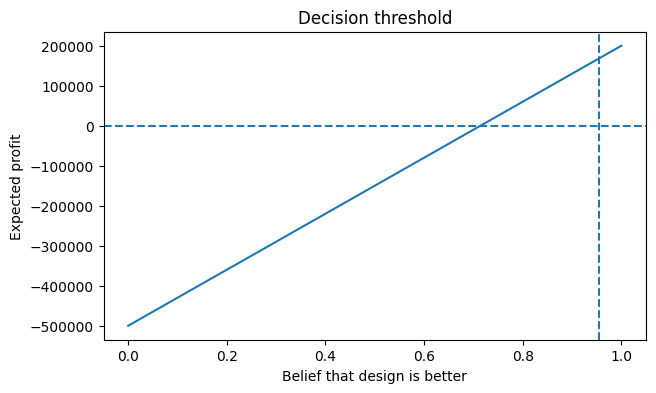

In [5]:
p = np.linspace(0,1,200)

ev = p * gain_if_better + (1-p) * loss_if_worse

plt.figure(figsize=(7,4))
plt.plot(p, ev)

plt.axhline(0, linestyle="--")
plt.axvline(p_better, linestyle="--")

plt.xlabel("Belief that design is better")
plt.ylabel("Expected profit")
plt.title("Decision threshold")

plt.show()